In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics  # This fixes your 'metrics' NameError

# 1. LOAD DATA
# Update this path if you moved the file
path = 'C://Users//HP 840 G5 I7//OneDrive//Desktop//MELBOURNE_HOUSE_PRICES_LESS.csv'
df = pd.read_csv(path)
df = df.dropna(subset=['Price'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48433 entries, 0 to 63020
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         48433 non-null  object 
 1   Address        48433 non-null  object 
 2   Rooms          48433 non-null  int64  
 3   Type           48433 non-null  object 
 4   Price          48433 non-null  float64
 5   Method         48433 non-null  object 
 6   SellerG        48433 non-null  object 
 7   Date           48433 non-null  object 
 8   Postcode       48433 non-null  int64  
 9   Regionname     48433 non-null  object 
 10  Propertycount  48433 non-null  int64  
 11  Distance       48433 non-null  float64
 12  CouncilArea    48433 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 5.2+ MB


In [7]:
# 2. DATA CLEANING & SELECTION (This creates 'df_filtered')
# We select these columns based on your specific dataset
cols_to_use = ['Rooms', 'Distance', 'Propertycount', 'Postcode', 'Type', 'Price']
df_filtered = df[cols_to_use].copy()

# One-Hot Encoding: Convert 'Type' (h, u, t) into numerical dummy variables [cite: 28, 39]
# This allows the regression model to process categorical data [cite: 13, 55]
df_filtered = pd.get_dummies(df_filtered, columns=['Type'], drop_first=True)

# Fill missing values with the median to avoid math errors
df_filtered = df_filtered.fillna(df_filtered.median())

print("Feature Engineering Complete!")
print("Columns now in dataset:", df_filtered.columns.tolist())
df.head()

Feature Engineering Complete!
Columns now in dataset: ['Rooms', 'Distance', 'Propertycount', 'Postcode', 'Price', 'Type_t', 'Type_u']


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


DATA TESTING

In [14]:
# 3. SPLIT DATA
X = df_filtered.drop('Price', axis=1)
y = df_filtered['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 5. MANUAL TEST
# Creating a dummy house with the same columns as X (Rooms, Distance, Propertycount, Postcode, Type_t, Type_u)
# Example: 3 Rooms, 10km away, 5000 count, 3000 postcode, Type = House (0,0)
my_house = pd.DataFrame([[4, 10.0, 4000, 3000, 0, 0]], columns=X.columns)
prediction = model.predict(my_house)

print(f"Manual Test Prediction: ${prediction[0]:,.2f}")



Manual Test Prediction: $1,316,792.85


In [15]:
# 6. EVALUATION
predictions = model.predict(X_test)

print('--- Melbourne House Price Prediction Results ---')
print(f'Mean Absolute Error (MAE): ${metrics.mean_absolute_error(y_test, predictions):,.2f}')
print(f'R^2 Score: {metrics.r2_score(y_test, predictions):.4f}')

--- Melbourne House Price Prediction Results ---
Mean Absolute Error (MAE): $309,937.34
R^2 Score: 0.3944


DATA VISUALISATIONS

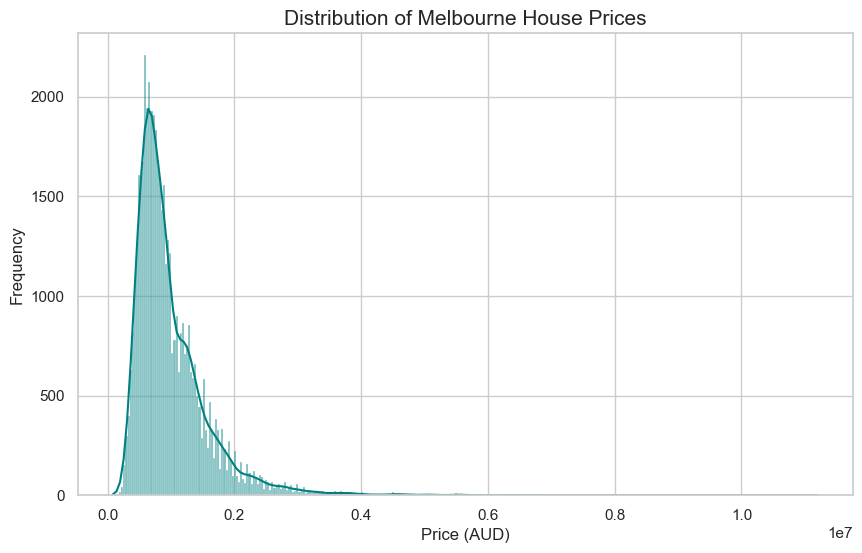

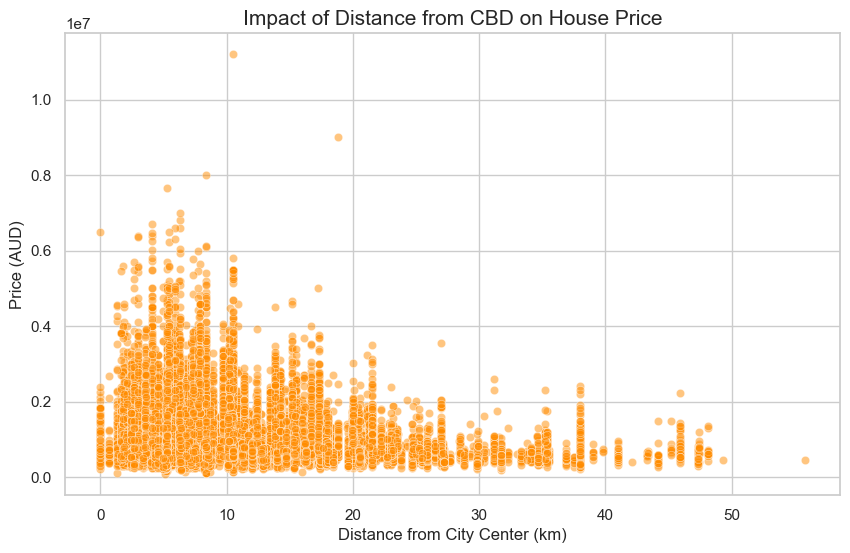

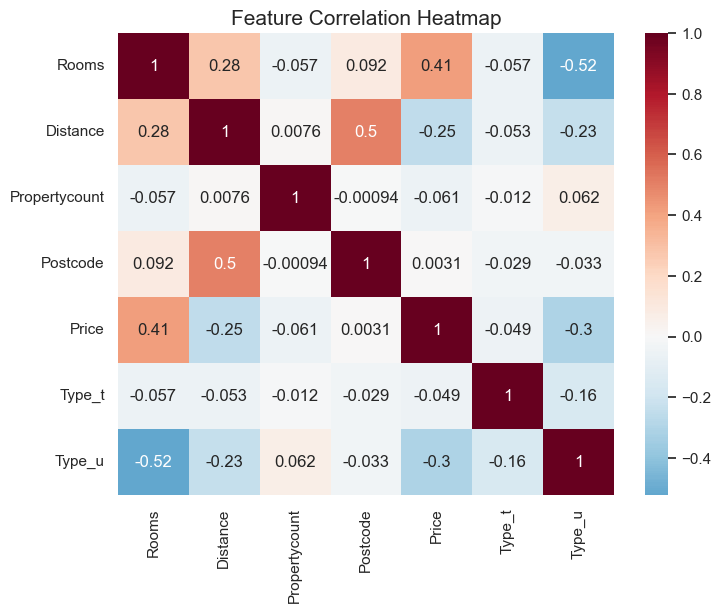

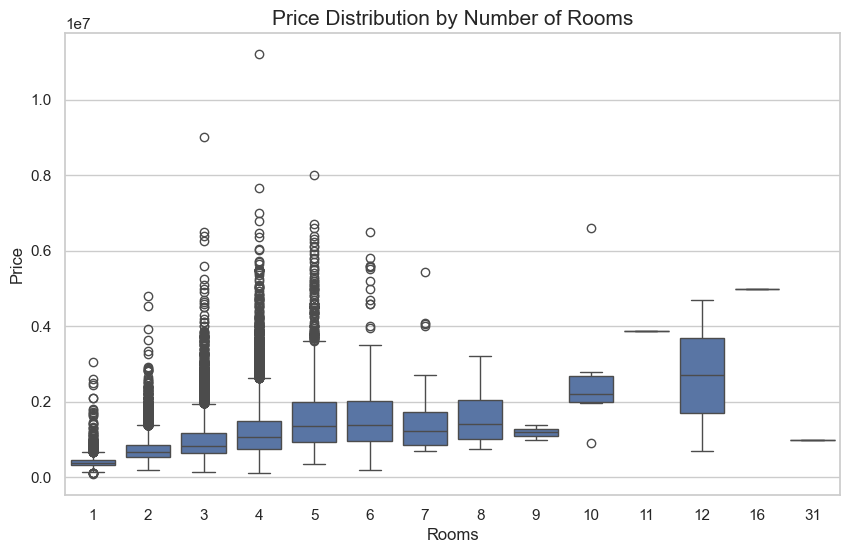

In [16]:
# ==========================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all plots
sns.set(style="whitegrid")

# 1. Histogram: Distribution of House Prices
# Identifies the spread and skewness of the target variable 
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['Price'], kde=True, color='teal')
plt.title('Distribution of Melbourne House Prices', fontsize=15)
plt.xlabel('Price (AUD)')
plt.ylabel('Frequency')
plt.show()

# 2. Scatter Plot: Price vs. Distance 
# Identifies the trend/correlation between location and value 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Distance', y='Price', alpha=0.5, color='darkorange')
plt.title('Impact of Distance from CBD on House Price', fontsize=15)
plt.xlabel('Distance from City Center (km)')
plt.ylabel('Price (AUD)')
plt.show()

# 3. Correlation Heatmap
# Summarizes statistical relationships between all numerical features 
plt.figure(figsize=(8, 6))
correlation_matrix = df_filtered.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.show()

# 4. Boxplot: Rooms vs Price
# Visualizes price distribution and outliers based on room count 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rooms', y='Price', data=df_filtered)
plt.title('Price Distribution by Number of Rooms', fontsize=15)
plt.show()